In [26]:
import pandas as pd 
import matplotlib.pyplot as plt

In [27]:
pd.set_option('display.max_columns', None)

In [28]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "datasets" / "raw" / "fake_job_postings.csv"
df = pd.read_csv(DATA_PATH)

In [29]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [30]:
print("Shape",df.shape)

Shape (17880, 18)


In [31]:
print(df.columns.tolist())

['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


In [32]:
df.dtypes

job_id                 int64
title                    str
location                 str
department               str
salary_range             str
company_profile          str
description              str
requirements             str
benefits                 str
telecommuting          int64
has_company_logo       int64
has_questions          int64
employment_type          str
required_experience      str
required_education       str
industry                 str
function                 str
fraudulent             int64
dtype: object

In [33]:
missing = df.isnull().sum().sort_values(ascending=False).to_frame("missing values")
print(missing)
missing["missing percentage"] = (missing["missing values"] / len(df)) * 100
print(missing["missing percentage"])

                     missing values
salary_range                  15012
department                    11547
required_education             8105
benefits                       7212
required_experience            7050
function                       6455
industry                       4903
employment_type                3471
company_profile                3308
requirements                   2696
location                        346
description                       1
title                             0
job_id                            0
telecommuting                     0
has_questions                     0
has_company_logo                  0
fraudulent                        0
salary_range           83.959732
department             64.580537
required_education     45.329978
benefits               40.335570
required_experience    39.429530
function               36.101790
industry               27.421700
employment_type        19.412752
company_profile        18.501119
requirements       

In [34]:
fraud = df['fraudulent'].value_counts()
print(fraud)
fraud_percentage = (df['fraudulent'].value_counts() / len(df)) * 100
print(fraud_percentage)

fraudulent
0    17014
1      866
Name: count, dtype: int64
fraudulent
0    95.1566
1     4.8434
Name: count, dtype: float64


In [35]:
distribution = pd.DataFrame({
    "count": fraud,
    "percentage": fraud_percentage
})
distribution

,count,percentage
fraudulent,,
0,17014,95.1566
1,866,4.8434


Text(0, 0.5, 'Count')

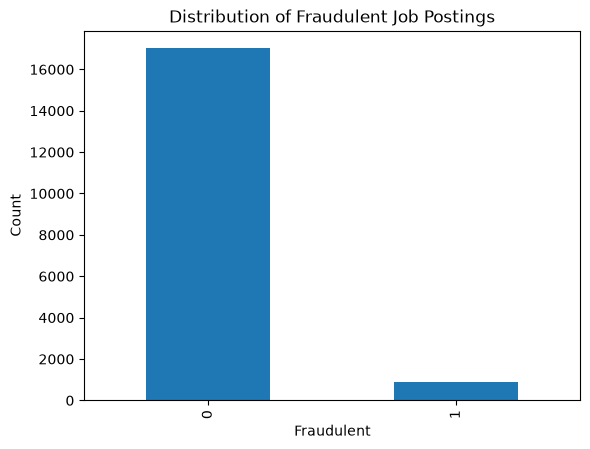

In [36]:
fraud.plot(kind='bar')
plt.title('Distribution of Fraudulent Job Postings')
plt.xlabel('Fraudulent')
plt.ylabel('Count')

In [37]:
"""Observations from the data Exploration:

1.The classes are pretty skewed — legit postings massively outnumber the fraudulent ones.
  That's going to matter a lot for how we train and evaluate the model (accuracy alone won't mean much here; we'll need to lean on precision/recall, F1, or resampling).

2.A lot of the text columns have missing values, and not a small amount either. Before jumping into modeling, 
  we need to figure out whether that missing data actually means "no info available" or if the absence itself is meaningful
 (e.g., scammers skipping certain fields on purpose).

3.There's a ton of high-cardinality text here — job descriptions, company profiles, requirements —
  so NLP is clearly going to be a core part of this project, not just a side step.

4.A few columns look like they might be saying the same thing in different words (title, description, requirements, benefits).
  Worth digging into during feature engineering to see if there's real overlap or redundancy we can trim


"""


'Observations from the data Exploration:\n\n1.The classes are pretty skewed — legit postings massively outnumber the fraudulent ones.\n  That\'s going to matter a lot for how we train and evaluate the model (accuracy alone won\'t mean much here; we\'ll need to lean on precision/recall, F1, or resampling).\n\n2.A lot of the text columns have missing values, and not a small amount either. Before jumping into modeling, \n  we need to figure out whether that missing data actually means "no info available" or if the absence itself is meaningful\n (e.g., scammers skipping certain fields on purpose).\n\n3.There\'s a ton of high-cardinality text here — job descriptions, company profiles, requirements —\n  so NLP is clearly going to be a core part of this project, not just a side step.\n\n4.A few columns look like they might be saying the same thing in different words (title, description, requirements, benefits).\n  Worth digging into during feature engineering to see if there\'s real overlap o